In [1]:
import numpy as np
import pyoti.sparse as oti
import itertools
from jetgp.full_ddegp.ddegp import ddegp
import jetgp.utils as utils

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 4
n_bases = 3
num_pts_per_axis = 3
domain_bounds = ((-1, 1),) * 3

# Slice visualization parameters
slice_dimension_index = 2    # Fix x₃
slice_dimension_value = 0.5  # Value of x₃
test_grid_resolution = 25

# Model and optimizer parameters
normalize_data = True
kernel = "RQ"
kernel_type = "isotropic"
n_restarts = 15
swarm_size = 50
random_seed = 0
np.random.seed(random_seed)

In [3]:
def true_function(X, alg=np):
    """True 3D polynomial function of degree 4."""
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return (x1**2 * x2 + x2**2 * x3 + x3**2 * x1 + x1**2 * x2**2)

In [4]:
def generate_training_data():
    """Generate 3D training data and apply global directional perturbations."""
    # 1. Create 3D grid of training points
    axis_points = [np.linspace(b[0], b[1], num_pts_per_axis)
                   for b in domain_bounds]
    X_train = np.array(list(itertools.product(*axis_points)))

    # 2. Standard basis as rays
    rays = np.eye(n_bases)

    # 3. Apply directional perturbations
    e_bases = [oti.e(i + 1, order=n_order) for i in range(rays.shape[1])]
    perturbations = np.dot(rays.T, e_bases)

    X_pert = oti.array(X_train)
    for j in range(n_bases):
        X_pert[:, j] += perturbations[j]

    f_hc = true_function(X_pert, alg=oti)
    for combo in itertools.combinations(range(1, rays.shape[1] + 1), 2):
        f_hc = f_hc.truncate(combo)

    # Extract derivatives
    y_train_list = [f_hc.real]
    der_indices = [[
        [[1, 1]], [[1, 2]], [[1, 3]], [[1, 4]],
        [[2, 1]], [[2, 2]], [[2, 3]], [[2, 4]],
        [[3, 1]], [[3, 2]], [[3, 3]], [[3, 4]],
    ]]

    for group in der_indices:
        for sub_group in group:
            y_train_list.append(f_hc.get_deriv(sub_group).reshape(-1, 1))

    return {'X_train': X_train, 'y_train_list': y_train_list,
            'der_indices': der_indices, 'rays': rays}

In [5]:
def train_model(training_data):
    """Initialize and train the D-DEGP model."""
    derivative_locations = []
    for i in range(len(training_data['der_indices'])):
        for j in range(len(training_data['der_indices'][i])):
            derivative_locations.append([i for i in range(len(training_data['X_train']))])
    gp_model = ddegp(
        training_data['X_train'], training_data['y_train_list'],
        n_order=n_order, der_indices=training_data['der_indices'],
        rays=training_data['rays'],derivative_locations=derivative_locations, normalize=normalize_data,
        kernel=kernel, kernel_type=kernel_type
    )

    params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = 5,
    debug = True
    )
    return gp_model, params

In [6]:
def evaluate_on_slice(gp_model, params):
    """Evaluate the GP model on a 2D slice of the 3D domain."""
    # Determine which two dimensions are active
    active_dims = [i for i in range(n_bases) if i != slice_dimension_index]

    x_lin = np.linspace(domain_bounds[active_dims[0]][0],
                        domain_bounds[active_dims[0]][1], test_grid_resolution)
    y_lin = np.linspace(domain_bounds[active_dims[1]][0],
                        domain_bounds[active_dims[1]][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)

    # Build 3D test points (fix x₃)
    X_test = np.full((X1_grid.size, n_bases), slice_dimension_value)
    X_test[:, active_dims[0]] = X1_grid.ravel()
    X_test[:, active_dims[1]] = X2_grid.ravel()

    y_pred = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)
    y_true = true_function(X_test, alg=np)
    nrmse_val = utils.nrmse(y_true, y_pred)

    return {'X_test': X_test, 'X1_grid': X1_grid, 'X2_grid': X2_grid,
            'y_pred': y_pred, 'y_true': y_true, 'nrmse': nrmse_val}

In [7]:
import matplotlib.pyplot as plt

def visualize_slice(training_data, results):
    """Visualize GP prediction and true function on 2D slice."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Reshape data for plotting
    y_pred_grid = results['y_pred'].reshape(results['X1_grid'].shape)
    y_true_grid = results['y_true'].reshape(results['X1_grid'].shape)
    abs_error_grid = np.abs(results['y_true'] - results['y_pred']).reshape(results['X1_grid'].shape)

    # GP Prediction
    c1 = axes[0].contourf(results['X1_grid'], results['X2_grid'], y_pred_grid,
                          levels=50, cmap="viridis")
    axes[0].set_title(f"GP Prediction (x₃={slice_dimension_value})")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    fig.colorbar(c1, ax=axes[0])

    # True Function
    c2 = axes[1].contourf(results['X1_grid'], results['X2_grid'], y_true_grid,
                          levels=50, cmap="viridis")
    axes[1].set_title("True Function")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    fig.colorbar(c2, ax=axes[1])

    # Absolute Error
    c3 = axes[2].contourf(results['X1_grid'], results['X2_grid'], abs_error_grid,
                          levels=50, cmap="magma")
    axes[2].set_title(f"Absolute Error (NRMSE={results['nrmse']:.4f})")
    axes[2].set_xlabel("$x_1$")
    axes[2].set_ylabel("$x_2$")
    fig.colorbar(c3, ax=axes[2])

    for ax in axes:
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

    print(f"  Visualization of slice at x₃={slice_dimension_value} created.")

Gen 1: best f=-599.2026326470244


Gen 2: best f=-1028.7382821038234


Gen 3: best f=-1028.7382821038234


Gen 4: best f=-1036.5167874258514


Local refinement at gen 5: nit=22, nfev=187, f=-1.808610e+03, success=True, message=CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Gen 5: best f=-1808.6104849289716


...

Gen 11: best f=-1808.6104849289716


Gen 12: best f=-1808.6104849289716


Gen 13: best f=-1808.6104849289716


Gen 14: best f=-1808.6104849289716


Gen 15: best f=-1808.6104849289716


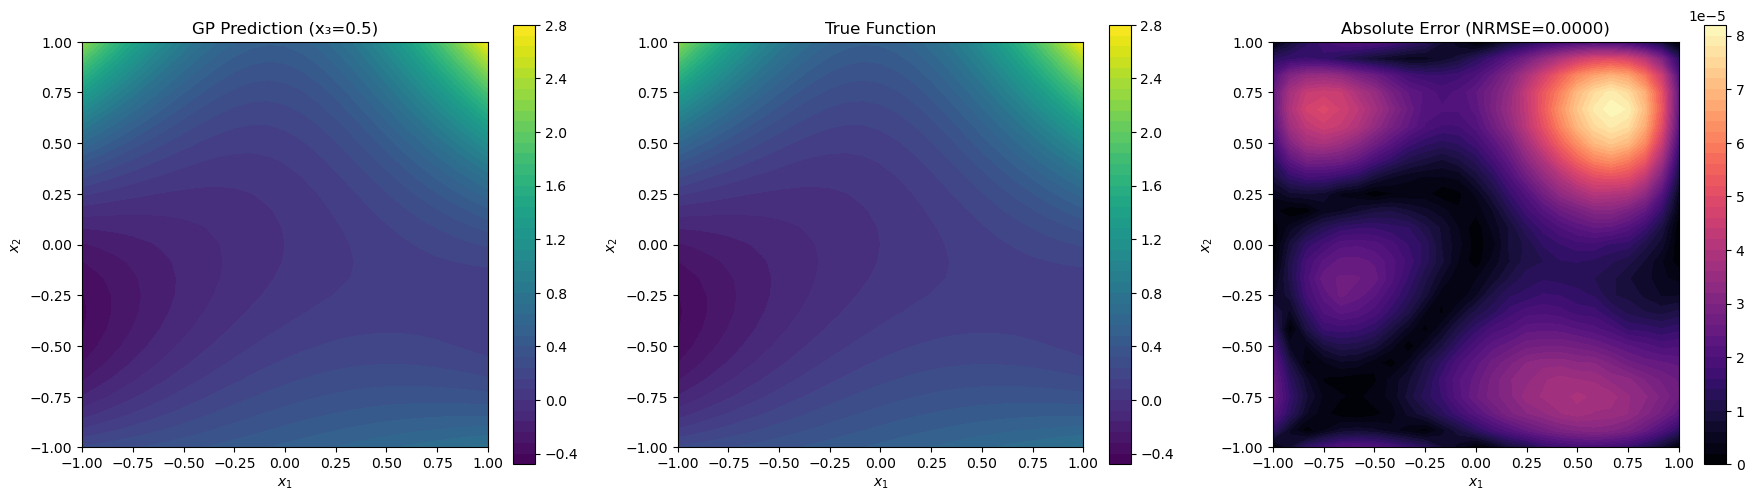

  Visualization of slice at x₃=0.5 created.
Final NRMSE on slice (x₃=0.5): 0.000008


In [8]:
training_data = generate_training_data()
gp_model, params = train_model(training_data)
results = evaluate_on_slice(gp_model, params)
visualize_slice(training_data, results)
print(f"Final NRMSE on slice (x₃={slice_dimension_value}): {results['nrmse']:.6f}")